#### `Customer Segmentation `  on `Wholesale Customers` using `Kmean` and `PCA` Algorithm

`Import Libraries`

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

`Loading dataset`

In [74]:
customer_seg = pd.read_csv('../dataset/wholesale_customer_data.csv')
customer_seg = customer_seg.drop(columns=['Channel', 'Region'])
customer_seg.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [75]:
print(customer_seg.shape)
print(customer_seg.info())

(440, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB
None


In [76]:
customer_seg.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


`Handling Missing Values`

In [77]:
customer_seg.isnull().sum().sort_values(ascending=False)

Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

`Data Visualization`

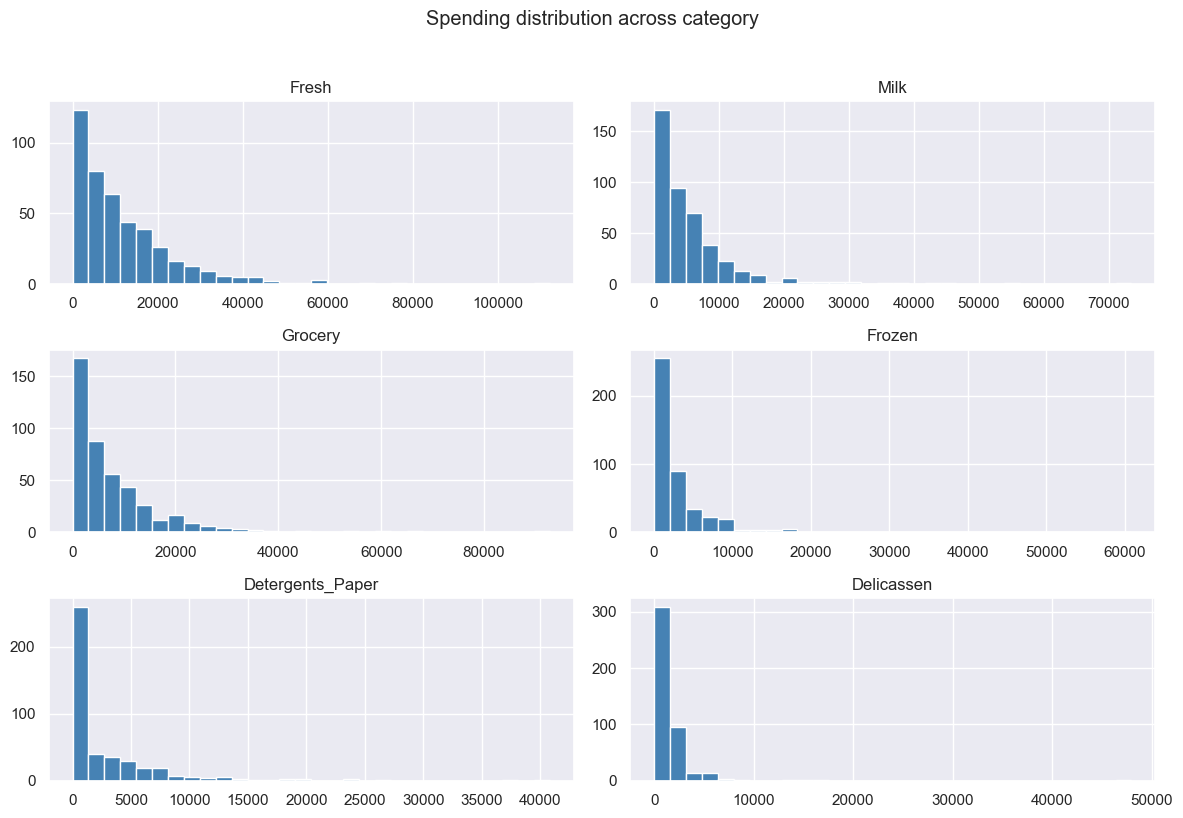

In [78]:
customer_seg.hist(bins=30, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Spending distribution across category', y = 1.02)
plt.tight_layout()
plt.show()

`Feature Scaling`

In [79]:
scaler  = StandardScaler()
scaled_customer_seg = scaler.fit_transform(customer_seg)

print('mean after scaling:', scaled_customer_seg.mean(axis=0).round(2))
print('std after scaling:', scaled_customer_seg.std(axis=0).round(2))

mean after scaling: [-0.  0. -0.  0.  0. -0.]
std after scaling: [1. 1. 1. 1. 1. 1.]


`Finding the Optimal Number of Clusters K`

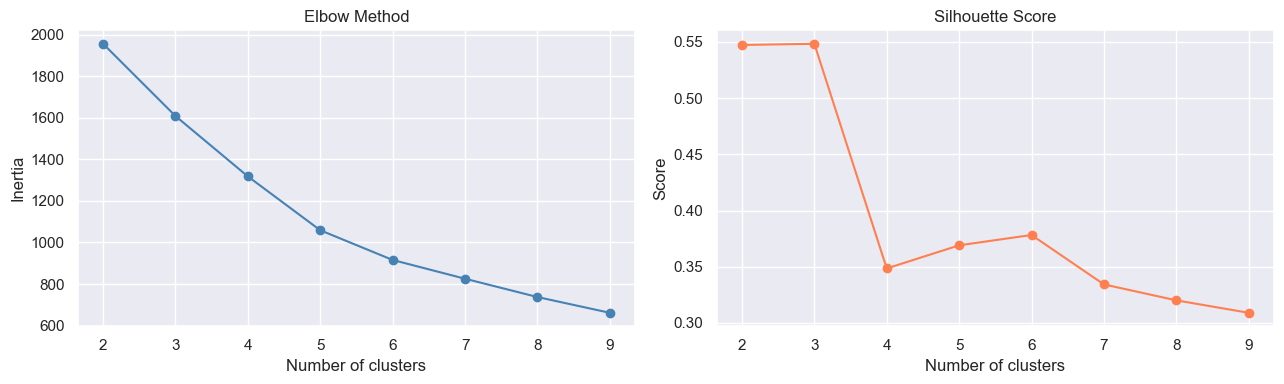

In [80]:
inertia = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_customer_seg)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_customer_seg, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_range, inertia, marker='o', color='steelblue')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, marker='o', color='coral')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

`Fitting K-Means`

In [81]:
K =3

km = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_seg['Cluster'] = km.fit_predict(scaled_customer_seg)

# show how many customers landed in each cluster
print(customer_seg['Cluster'].value_counts())

Cluster
0    198
8    106
7     44
3     42
4     36
1      7
2      4
5      2
6      1
Name: count, dtype: int64


`Visualizing with PCA`

Variance explained: 72.5%


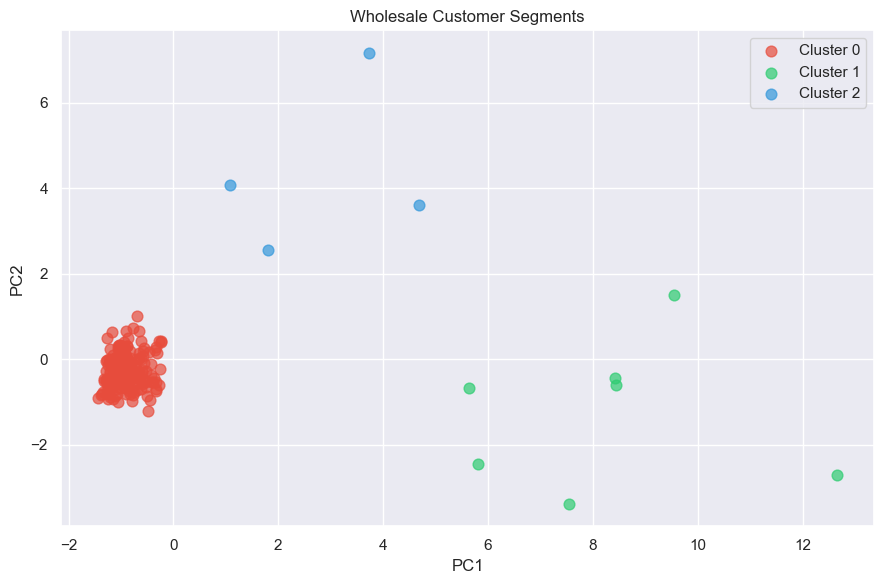

In [82]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(scaled_customer_seg)

customer_seg["PC1"] = components[:, 0]
customer_seg["PC2"] = components[:, 1]

# How much variance is preserved?
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(9, 6))
colors = ["#E74C3C", "#2ECC71", "#3498DB"]
for i in range(K):
    subset = customer_seg[customer_seg["Cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"],
                label=f"Cluster {i}", color=colors[i], s=60, alpha=0.7)

plt.title("Wholesale Customer Segments")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

`Profiling and Understanding each Cluster`

In [83]:
profile = customer_seg.groupby("Cluster")[
    ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
].mean().round(0)

print(profile)

           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                  
0         8686.0   2235.0   2862.0   1853.0             654.0       872.0
1        20031.0  38084.0  56126.0   2565.0           27645.0      2548.0
2        50020.0  18085.0  17332.0   8396.0            3759.0     13474.0
3        14810.0   3658.0   3895.0  10039.0             492.0      1390.0
4         5308.0  14993.0  23791.0   1631.0           11026.0      1776.0
5        22016.0   9937.0   7844.0  47939.0             672.0      4154.0
6        36847.0  43950.0  20170.0  36534.0             239.0     47943.0
7        36860.0   4197.0   5421.0   3827.0             900.0      1777.0
8         6643.0   7803.0  11087.0   1434.0            4443.0      1601.0


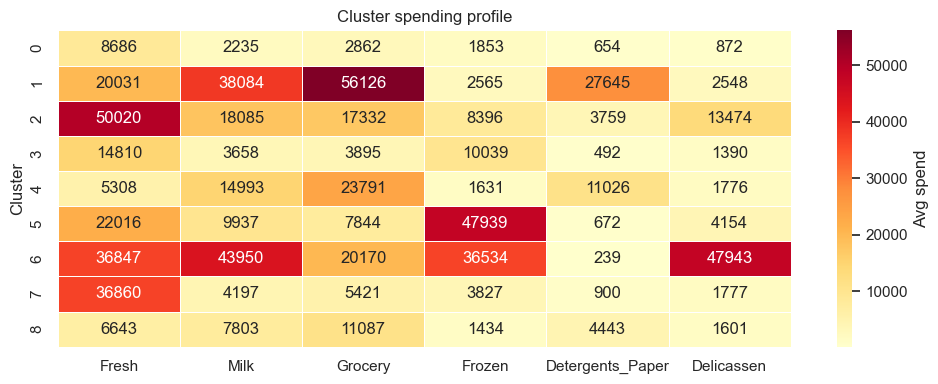

In [84]:
plt.figure(figsize=(10, 4))
sns.heatmap(profile, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Avg spend"})
plt.title("Cluster spending profile")
plt.tight_layout()
plt.show()

In [85]:
# Assign meaningful labels (adjust based on your actual output)
label_map = {0: "Restaurants", 1: "Retailers", 2: "Small Shops"}
customer_seg["Segment"] = customer_seg["Cluster"].map(label_map)
print(customer_seg["Segment"].value_counts())

Segment
Restaurants    198
Retailers        7
Small Shops      4
Name: count, dtype: int64


`Bar Chart Segment`

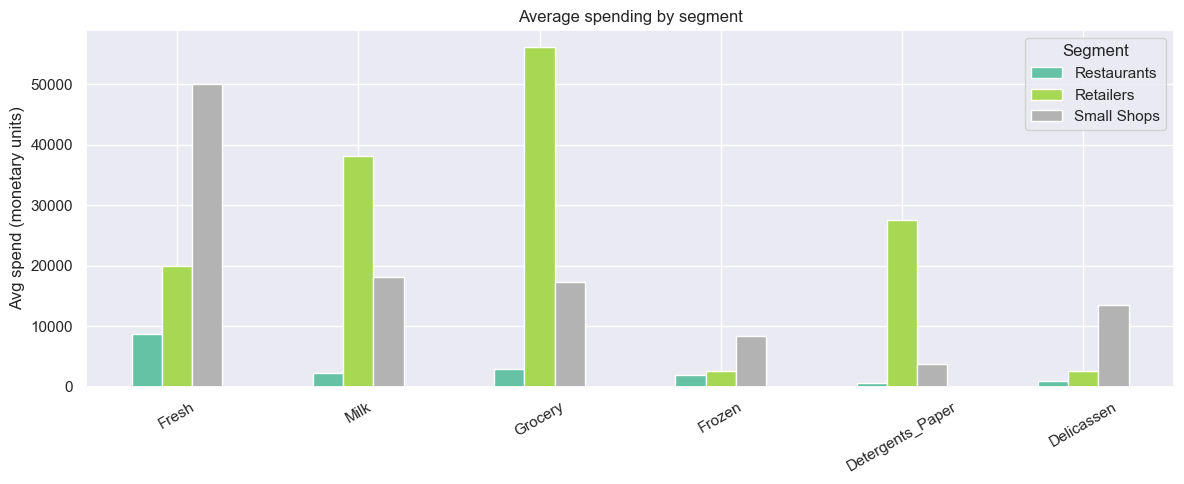

In [87]:
segment_means = customer_seg.groupby("Segment")[
    ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"]
].mean()

segment_means.T.plot(kind="bar", figsize=(12, 5), colormap="Set2", edgecolor="white")
plt.title("Average spending by segment")
plt.ylabel("Avg spend (monetary units)")
plt.xticks(rotation=30)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()